# Historical POV Exploration — Auto-Tuning Case Studies

Two real production tasks examined through the lens of the auto-tuning framework.

| Case | Task | Tenant | Key insight |
|---|---|---|---|
| Part 1 | `Impression-Pre-Process` (app_id=159) | internal | `over_provisioned_driver_cores`: 32 → 1, $463/yr |
| Part 2 | `ENGAGEMENT` (app_id=455) | Nexxen / DM2 | Manual 8-phase tuning: −97% cost; what the engine would have done |


---
# Part 1 — Impression-Pre-Process

**Task**: `Impression-Pre-Process` · app_id=159 · insight_id=378733  
**Insight**: `over_provisioned_driver_cores` — reduce `spark.driver.cores` from 32 → 1  
**Potential annual saving**: $463/year  

This section:
1. Loads the raw 5-run CSV snapshot (`data/case_studies/Impression-Pre-Process.csv`)
2. Computes `TaskRunMetrics` and checks each blocking rule
3. Simulates the full driver-cores tuning loop (9-step staircase, 12 runs)
4. Demonstrates the Issue #5 external-shift scenario with real cost numbers


In [1]:
import sys, json, math, statistics
import pandas as pd
import matplotlib, matplotlib.pyplot as plt

import os
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "data" / "case_studies").is_dir() and (ROOT.parent / "data" / "case_studies").is_dir():
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT / "scripts"))
from paths import cost_optimizer_root, definity_backend_root

ROOT = cost_optimizer_root()
BACKEND = definity_backend_root()
if str(BACKEND) not in sys.path:
    sys.path.insert(0, str(BACKEND))

from app.brain.insights.tuning import (
    create_knob_state, get_initial_next_value, process_run_outcome,
    RunOutcome, KnobTuningState,
    build_tuning_plan, ActiveInsight, TuningConstraints,
)
from app.brain.insights.tuning.run_metrics import TaskRunMetrics, compute_run_metrics
from app.brain.insights.tuning.blocking import check_blocking
from app.brain.insights.tuning.step import build_staircase
from app.brain.insights.tuning.knob_registry import KNOB_REGISTRY


### Refetch Impression-Pre-Process (optional)

The committed snapshot lives at `data/case_studies/Impression-Pre-Process.csv`.

To regenerate from prod, set `DATABASE_URL` and run the cell below. It uses the same join as `data_exploration.ipynb` (`TASKS_QUERY`) filtered to `app_id=159`, `task_name='Impression-Pre-Process'`, Sep 28 – Oct 2 2025.


In [ ]:
import os
from datetime import datetime, timezone
from pathlib import Path

import pandas as pd
from sqlalchemy import create_engine, text

ROOT = Path.cwd()
if not (ROOT / "data" / "case_studies").is_dir() and (ROOT.parent / "data" / "case_studies").is_dir():
    ROOT = ROOT.parent

DATABASE_URL = os.environ.get("DATABASE_URL")
CASE_CSV = ROOT / "data" / "case_studies" / "Impression-Pre-Process.csv"

IMPRESSION_TASKS_QUERY = text("""
SELECT
    i.insight_id,
    i.type AS insight_type,
    i.impact_cost,
    i.impact_unit,
    i.insights_payload,
    t.app_id,
    t.task_name,
    t.task_id,
    t.app_pit,
    t.start_time,
    t.end_time,
    t.status,
    te.task__duration AS task_duration_seconds,
    te.task__total_io_bytes AS total_io_bytes,
    te.task__disk_bytes_spilled AS disk_bytes_spilled,
    te.driver__cores AS spark_driver_cores,
    te.driver__heap_memory__allocated AS spark_driver_memory_gb,
    te.executor__memory_heap__allocated AS spark_executor_memory_gb,
    te.task__executors_dynamic_allocation_max_executors__param AS spark_dynamic_alloc_max_executors,
    te.task__executor_instances__param AS spark_executor_instances,
    te.task__shuffle_partitions__param AS spark_shuffle_partitions,
    te.task__task_cpus__param AS spark_task_cpus,
    te.executor__cores AS spark_executor_cores,
    te.task__dynamic_is_allocation_enabled__param AS is_dynamic_allocation,
    te.task__vcore_time__used AS vcore_seconds_used,
    te.task__memory_time__allocated AS memory_gb_seconds_allocated,
    te.executors__memory_time__used AS memory_gb_seconds_used,
    (
        te.task__vcore_time__allocated * ts.vcore_price / 3600
        + te.task__memory_time__allocated * ts.memory_price / 3600
    ) AS run_cost_usd,
    ts.vcore_price,
    ts.memory_price,
    ts.machine_memory_to_vcore_ratio,
    CASE
        WHEN i.impact_unit = 'VCore' THEN i.impact_cost * ts.vcore_price / 3600
        WHEN i.impact_unit = 'GB' THEN i.impact_cost * ts.memory_price / 3600
        ELSE i.impact_cost
    END AS insight_usd_cost
FROM tasks AS t
JOIN task_enrichments AS te ON te.task_id = t.task_id
JOIN tenant_settings AS ts ON ts.tenant_id = t.tenant_id
LEFT JOIN insights AS i
    ON i.app_id = t.app_id AND i.task_name = t.task_name AND i.type != 'task_profile'
WHERE t.app_id = 159
  AND t.task_name = 'Impression-Pre-Process'
  AND t.start_time >= :start_ts
  AND t.start_time < :end_ts
ORDER BY t.start_time
""")

# Uncomment to refetch (requires DATABASE_URL):
# if not DATABASE_URL:
#     raise RuntimeError("Set DATABASE_URL to refetch")
# start = datetime(2025, 9, 28, tzinfo=timezone.utc)
# end = datetime(2025, 10, 3, tzinfo=timezone.utc)
# engine = create_engine(DATABASE_URL)
# with engine.connect() as conn:
#     df_fetch = pd.read_sql(IMPRESSION_TASKS_QUERY, conn, params={"start_ts": start, "end_ts": end})
# df_fetch.to_csv(CASE_CSV, index=False)
# print(f"Wrote {len(df_fetch)} rows to {CASE_CSV}")
print(f"Using committed snapshot: {CASE_CSV}")


In [2]:
import pathlib

CSV = ROOT / 'data' / 'case_studies' / 'Impression-Pre-Process.csv'

df = pd.read_csv(CSV)
print(f'Loaded {len(df)} rows, {len(df.columns)} columns')
df[['task_id','start_time','task_duration_seconds','input_records_read',
    'disk_bytes_spilled','run_cost_usd','spark_driver_cores']]


Loaded 5 rows, 66 columns


,task_id,start_time,task_duration_seconds,input_records_read,disk_bytes_spilled,run_cost_usd,spark_driver_cores
0,502863,2025-09-28 14:13:33.169+00,6413.661,81525756731,14123702306,60.436278,32
1,509799,2025-09-29 14:18:55.285+00,3271.263,36826485744,14123729774,29.301908,32
2,518213,2025-09-30 14:18:29.461+00,1689.325,14809821070,14123729774,14.229057,32
3,525236,2025-10-01 14:18:30.57+00,1872.327,19823534331,14123706655,16.350518,32
4,531795,2025-10-02 14:18:43.843+00,2032.226,20237498868,14123729774,17.911883,32


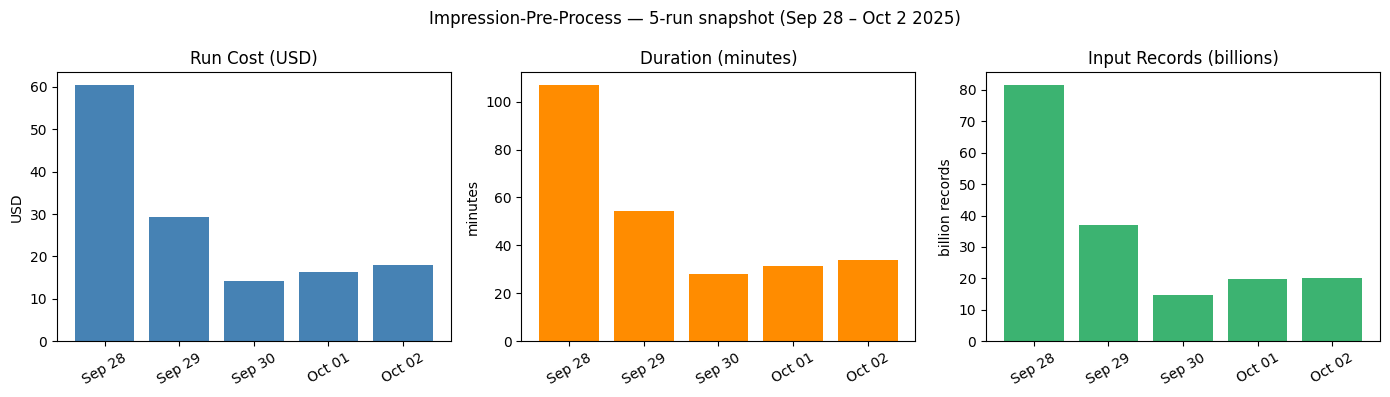

Key observation: input records shrank 5.5× in 48 h, but spill bytes stayed ~14 GB
→ spill comes from a static join partner (broadcast not possible), not input volume


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

dates = pd.to_datetime(df['start_time']).dt.strftime('%b %d')
axes[0].bar(dates, df['run_cost_usd'], color='steelblue')
axes[0].set_title('Run Cost (USD)')
axes[0].set_ylabel('USD')

axes[1].bar(dates, df['task_duration_seconds'] / 60, color='darkorange')
axes[1].set_title('Duration (minutes)')
axes[1].set_ylabel('minutes')

axes[2].bar(dates, df['input_records_read'] / 1e9, color='mediumseagreen')
axes[2].set_title('Input Records (billions)')
axes[2].set_ylabel('billion records')

for ax in axes:
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('Impression-Pre-Process — 5-run snapshot (Sep 28 – Oct 2 2025)', fontsize=12)
plt.tight_layout()
plt.show()

print('Key observation: input records shrank 5.5× in 48 h, but spill bytes stayed ~14 GB')
print('→ spill comes from a static join partner (broadcast not possible), not input volume')


## Run Metrics & Blocking Rules

We map the CSV columns to the names `compute_run_metrics` expects, then check which blocking rules fire for `spark.driver.cores` (the tuning candidate) and for `spark.executor.memory` (to verify spill blocks memory reduction).

In [4]:
# Map CSV columns → enrichment dict keys expected by compute_run_metrics
def row_to_enrichment(row):
    return {
        'executor__memory_heap__allocated':  row.get('executor_heap_memory_allocated_gb', 0) * 1024**3,
        'executor__memory_heap__max_used':   row.get('executor_heap_memory_peak_gb', 0)    * 1024**3,
        'executor__memory_off_heap__allocated': row.get('executor_off_heap_memory_allocated_gb', 0) * 1024**3,
        'executor__memory_off_heap__max_used':  row.get('executor_off_heap_memory_peak_gb', 0)     * 1024**3,
        'executors__vcore_time__used':      row.get('executors_vcore_seconds_used', 0),
        'executors__vcore_time__allocated': row.get('executors_vcore_seconds_allocated', 0),
        'task__idle_time':                  row.get('task_idle_seconds', 0),
        'task__duration':                   row.get('task_duration_seconds', 1),
        'task__skew_time':                  row.get('task_skew_seconds', 0),
        'task__disk_bytes_spilled':         row.get('disk_bytes_spilled', 0),
        'task__total_io_bytes':             row.get('total_io_bytes', 0),
        'executors__jvm_gc_time':           row.get('executors_jvm_gc_seconds', 0) * 1000,
        'executors__run_time__used':        row.get('executors_run_time_seconds', 1) * 1000,
        'executors__cpu_time__used':        row.get('executors_cpu_time_seconds', 0) * 1e9,
        'executors__used_vcore_time_of_retried_tasks': row.get('vcore_seconds_wasted_on_retries', 0),
    }

# Use the last (most recent) row as representative metrics
last_row = df.iloc[-1].to_dict()
enrichment = row_to_enrichment(last_row)
metrics = compute_run_metrics(enrichment)

signals = [
    ('memory_headroom',   metrics.memory_headroom),
    ('gc_pressure',       metrics.gc_pressure),
    ('off_heap_headroom', metrics.off_heap_headroom),
    ('vcore_utilization', metrics.vcore_utilization),
    ('idle_ratio',        metrics.idle_ratio),
    ('skew_ratio',        metrics.skew_ratio),
    ('has_spill',         metrics.has_spill),
    ('spill_ratio',       metrics.spill_ratio),
]
pd.DataFrame(signals, columns=['signal', 'value'])


,signal,value
0,memory_headroom,0.683086
1,gc_pressure,0.003097
2,off_heap_headroom,0.961367
3,vcore_utilization,0.525417
4,idle_ratio,0.109498
5,skew_ratio,0.0
6,has_spill,True
7,spill_ratio,0.00711


In [5]:
# Check blocking rules for the two most relevant config keys
DRIVER_CORES  = 'spark.driver.cores'
EXEC_MEMORY   = 'spark.executor.memory'

results = []
for key, cur, tgt in [
    (DRIVER_CORES, 32,  1),
    (EXEC_MEMORY,  204, 100),  # hypothetical: reduce executor heap by ~half
]:
    blocked, reason = check_blocking(key, cur, tgt, task_profile=None, run_metrics=metrics)
    results.append({'config_key': key, 'blocked': blocked, 'reason': reason or '—'})

df_block = pd.DataFrame(results)
print('Blocking rule analysis')
print(df_block.to_string(index=False))
print()
print('spark.driver.cores: NOT in _EXECUTOR_KEYS or _MEMORY_KEYS → spill rule cannot fire')
print('spark.executor.memory: has_spill=True + direction=decrease → Rule 2 fires → BLOCKED')


Blocking rule analysis
           config_key  blocked                                                                                                        reason
   spark.driver.cores    False                                                                                                             —
spark.executor.memory     True Active spill detected — reducing executor memory while spill is present risks worsening spill or causing OOM.

spark.driver.cores: NOT in _EXECUTOR_KEYS or _MEMORY_KEYS → spill rule cannot fire
spark.executor.memory: has_spill=True + direction=decrease → Rule 2 fires → BLOCKED


## Driver Cores Staircase (32 → 1)

`spark.driver.cores` uses `pct_cap=0.25`, `abs_cap=2`.  Each step is `min(|Δ|, max(2, current × 0.25))`.

Staircase: [24, 18, 14, 10, 8, 6, 4, 2, 1]
Steps to target: 9


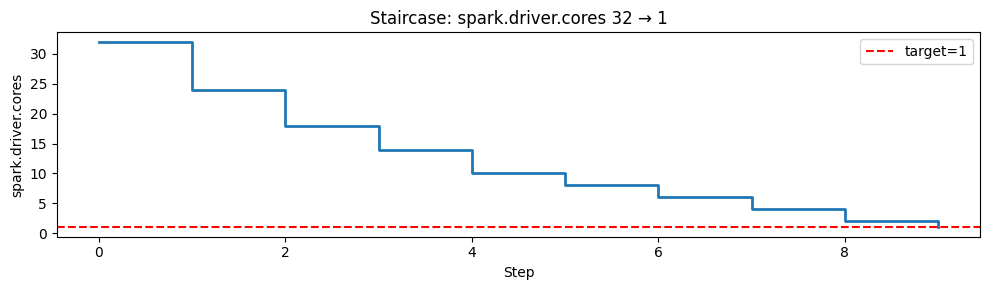

In [6]:
cap = KNOB_REGISTRY['spark.driver.cores']
staircase = build_staircase(32, 1, cap,
                            constraints_default_pct=0.20,
                            constraints_default_abs=5)
print('Staircase:', staircase)
print(f'Steps to target: {len(staircase)}')

# Visualise
fig, ax = plt.subplots(figsize=(10, 3))
ax.step(range(len(staircase) + 1), [32] + list(staircase), where='post', lw=2)
ax.axhline(1, color='red', linestyle='--', label='target=1')
ax.set_xlabel('Step')
ax.set_ylabel('spark.driver.cores')
ax.set_title('Staircase: spark.driver.cores 32 → 1')
ax.legend()
plt.tight_layout()
plt.show()


## Full Tuning Loop Simulation

Simulate 12 runs with stable cost (~$17.91) and no regression.
The staircase has 9 steps + 3 confirmation runs = 12 total.

Phase icons: `→` search · `✓` confirming · `★` completed · `✗` abandoned · `⏸` paused

In [7]:
PHASE_ICON = {'search': '→', 'confirming': '✓', 'completed': '★',
              'abandoned': '✗', 'paused': '⏸'}

# Pre-tuning baselines from CSV rows 1–3
baseline_durations_ms = [6413_661, 3271_263, 1689_325]
pre_tuning_cost       = 17.91   # last stable run (Oct 2)

state = create_knob_state(
    config_key='spark.driver.cores',
    current_value=32,
    target_value=1,
    pre_tuning_durations_ms=baseline_durations_ms,
    pre_tuning_cost_usd=pre_tuning_cost,
)

next_val = get_initial_next_value(state)
rows = []
for run_num in range(1, 16):
    if state.phase in ('completed', 'abandoned'):
        break
    outcome = RunOutcome(
        applied_value=next_val,
        job_status='success',
        run_cost_usd=pre_tuning_cost * 0.95,   # steady ~5% cheaper
        run_duration_ms=2032_000,              # stable ~34 min
    )
    state, dec = process_run_outcome(state, outcome)
    rows.append({
        'run':    run_num,
        'applied': next_val,
        'action': dec.next_action,
        'phase':  PHASE_ICON[state.phase] + ' ' + state.phase,
        'next':   dec.next_value,
        'reason': state.phase_reason[:70],
    })
    next_val = dec.next_value

pd.set_option('display.max_colwidth', 80)
pd.DataFrame(rows)


,run,applied,action,phase,next,reason
0,1,24,advance,→ search,18.0,advancing: 24 → 18
1,2,18,advance,→ search,14.0,advancing: 18 → 14
2,3,14,advance,→ search,10.0,advancing: 14 → 10
3,4,10,advance,→ search,8.0,advancing: 10 → 8
4,5,8,advance,→ search,6.0,advancing: 8 → 6
5,6,6,advance,→ search,4.0,advancing: 6 → 4
6,7,4,advance,→ search,2.0,advancing: 4 → 2
7,8,2,advance,→ search,1.0,advancing: 2 → 1
8,9,1,stay,✓ confirming,1.0,confirming: 1/3 clean runs (2 more needed)
9,10,1,stay,✓ confirming,1.0,confirming: 2/3 clean runs (1 more needed)


---
# Part 2 — ENGAGEMENT (Nexxen / DM2 ENGAGEMENT)

**Tenant**: Nexxen (tenant_id=3)  
**Pipeline**: DM2 ENGAGEMENT · app_id=455  
**Task**: ENGAGEMENT  
**Data source**: `data/case_studies/ENGAGEMENT_runs.csv` (see refetch SQL in cells below).  

This section is a **historical post-mortem** of a manual tuning campaign that cut costs ~97% over 3 months (Jul–Oct 2025), and analyses what the auto-tuning mechanism would have done differently.

**Three questions:**
1. What config changes caused the mid-Aug 2025 cost drop, and is the 'executors up, vCores down' observation explained?
2. What would the tuning mechanism have proposed starting from Phase 1 (Aug 18 baseline)?
3. What improvements does this case suggest for the tuning engine?


### Refetch ENGAGEMENT runs (optional)

Committed snapshot: `data/case_studies/ENGAGEMENT_runs.csv`.

The query below reconstructs the Grafana export from `tasks` + `task_enrichments`
for `app_id=455`, `task_name='ENGAGEMENT'`. Column names match the CSV schema
(`vcore_ks_*` = vCore-seconds / 1000). Uncomment the fetch block in the next cell
to regenerate (requires `DATABASE_URL`).


In [ ]:
import os
from datetime import datetime, timezone
from pathlib import Path

import pandas as pd
from sqlalchemy import create_engine, text

ROOT = Path.cwd()
if not (ROOT / "data" / "case_studies").is_dir() and (ROOT.parent / "data" / "case_studies").is_dir():
    ROOT = ROOT.parent

DATABASE_URL = os.environ.get("DATABASE_URL")
CASE_CSV = ROOT / "data" / "case_studies" / "ENGAGEMENT_runs.csv"

ENGAGEMENT_RUNS_QUERY = text("""
SELECT
    t.task_id,
    (EXTRACT(EPOCH FROM t.start_time) * 1000)::bigint AS start_time_ms,
    t.start_time AS start_date,
    (EXTRACT(EPOCH FROM t.end_time) * 1000)::bigint AS end_time_ms,
    t.status,
    te.task__duration AS duration_s,
    te.task__executors_dynamic_allocation_max_executors__param AS dyn_max_executors,
    te.task__executors_dynamic_allocation_min_executors__param AS dyn_min_executors,
    te.task__executor_instances__param AS executor_instances,
    te.executor__cores AS executor_cores,
    te.executor__memory_heap__allocated AS heap_alloc_gb,
    te.executor__memory_heap__max_used AS heap_used_gb,
    te.task__shuffle_partitions__param AS shuffle_partitions,
    te.task__vcore_time__allocated / 1000.0 AS vcore_ks_alloc,
    te.task__vcore_time__used / 1000.0 AS vcore_ks_used,
    CASE
        WHEN te.task__vcore_time__allocated > 0
        THEN 100.0 * te.task__vcore_time__used / te.task__vcore_time__allocated
    END AS vcore_util_pct,
    CASE
        WHEN te.executor__memory_heap__allocated > 0
        THEN 1.0 - te.executor__memory_heap__max_used / te.executor__memory_heap__allocated
    END AS heap_headroom,
    CASE
        WHEN te.task__duration > 0
        THEN 100.0 * te.executors__jvm_gc_time / te.task__duration
    END AS gc_pct,
    te.task__disk_bytes_spilled / 1e9 AS spill_gb,
    CASE
        WHEN te.task__duration > 0 AND te.task__duration IS NOT NULL
        THEN 100.0 * COALESCE(te.task__idle_time, 0) / te.task__duration
    END AS idle_pct,
    CASE
        WHEN te.task__duration > 0 AND te.task__duration IS NOT NULL
        THEN 100.0 * COALESCE(te.task__skew_time, 0) / te.task__duration
    END AS skew_pct,
    te.cluster_max_workers,
    te.cluster_min_workers,
    te.worker_type,
    te.cloud_provider
FROM tasks AS t
JOIN task_enrichments AS te ON te.task_id = t.task_id
WHERE t.app_id = 455
  AND t.task_name = 'ENGAGEMENT'
  AND t.start_time >= :start_ts
  AND t.start_time < :end_ts
ORDER BY t.start_time
""")

# Uncomment to refetch (requires DATABASE_URL):
# if not DATABASE_URL:
#     raise RuntimeError("Set DATABASE_URL to refetch")
# start = datetime(2025, 7, 1, tzinfo=timezone.utc)
# end = datetime(2026, 7, 1, tzinfo=timezone.utc)
# engine = create_engine(DATABASE_URL)
# with engine.connect() as conn:
#     df_eng_fetch = pd.read_sql(ENGAGEMENT_RUNS_QUERY, conn, params={"start_ts": start, "end_ts": end})
# df_eng_fetch.to_csv(CASE_CSV, index=False)
# print(f"Wrote {len(df_eng_fetch):,} rows to {CASE_CSV}")
print(f"Using committed snapshot: {CASE_CSV}")


In [ ]:
import sys
import math
import statistics
import os
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "data" / "case_studies").is_dir() and (ROOT.parent / "data" / "case_studies").is_dir():
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT / "scripts"))
from paths import cost_optimizer_root, definity_backend_root

ROOT = cost_optimizer_root()
BACKEND = definity_backend_root()
if str(BACKEND) not in sys.path:
    sys.path.insert(0, str(BACKEND))

from app.brain.insights.tuning.step import build_staircase
from app.brain.insights.tuning.knob_registry import KNOB_REGISTRY

PHASE_ICON = {
    "search": "→",
    "confirming": "✓",
    "completed": "★",
    "abandoned": "✗",
    "paused": "⏸",
}

CSV_PATH = ROOT / "data" / "case_studies" / "ENGAGEMENT_runs.csv"
df_runs = pd.read_csv(CSV_PATH)
df_runs["start_date"] = pd.to_datetime(df_runs["start_date"], utc=True, errors="coerce")
df_runs = df_runs.dropna(subset=["start_date"]).sort_values("start_date").reset_index(drop=True)

print(f"Loaded {len(df_runs):,} runs")
print(f"Date range: {df_runs['start_date'].dt.date.min()} → {df_runs['start_date'].dt.date.max()}")
df_runs.head(3)


## Phase Evolution (Jul 2025 – Jun 2026)

Each row is a distinct config cluster observed in `task_enrichments`.  
**vCore cap** = `dyn_max × exec_cores` — the total executor vCore budget per run.

In [ ]:
# ── Derive phases: assign phase_id to each run based on consecutive config state ──
CONFIG_COLS = ['dyn_max_executors', 'executor_instances', 'executor_cores', 'shuffle_partitions']

# Detect config transitions (phase_id increments on each change)
config_str = df_runs[CONFIG_COLS].astype(str).apply('|'.join, axis=1)
phase_id   = (config_str != config_str.shift()).cumsum()
df_runs['phase_id'] = phase_id

# Phase notes from production audit
_NOTES = {
    1: 'Default config — no Spark params set explicitly',
    2: 'Manual: dyn_max 1600→487 (−70%), memOverhead +1024 MB, shuffle 200→400',
    3: 'Manual: small dyn_max trim 487→473',
    4: 'Manual: dyn_max 473→187, instances 400→180 — best utilization yet',
    5: '⚠️ TRAP: instances 180→120 BUT cores 1→2 → vCores cap doubled 187→374 → cost UP',
    6: 'Manual: instances→80, cores→3, heap 20→31 GB',
    7: 'Manual: dyn_max 187→54 (large step)',
    8: 'Brief reversion (14 runs) before final config',
    9: 'Manual: cores 3→4, shuffle 800→1600  (current config)',
}

def summarise_phase(grp):
    pid  = int(grp['phase_id'].iloc[0])
    r0   = grp.iloc[0]
    cores = int(r0['executor_cores'] or 1)
    dyn   = int(r0['dyn_max_executors'] or 0)
    # Filter to runs with valid vcore data
    valid = grp[(grp['vcore_ks_alloc'] > 0) & (grp['duration_s'] > 200)]
    med_ks   = valid['vcore_ks_alloc'].median()
    med_util = valid['vcore_util_pct'].median()
    med_dur  = valid['duration_s'].median()
    # Derive average active executors from vcore_ks / (cores × duration_s / 1000)
    avg_active = valid['vcore_ks_alloc'] * 1000 / (cores * valid['duration_s'])
    p95_act    = avg_active.quantile(0.95) if len(avg_active) > 10 else None
    return pd.Series({
        'start':        grp['start_date'].min().strftime('%Y-%m-%d'),
        'end':          grp['start_date'].max().strftime('%Y-%m-%d'),
        'n_runs':       len(grp),
        'dyn_max':      dyn,
        'instances':    int(r0['executor_instances'] or 0),
        'cores':        cores,
        'shuffle':      r0['shuffle_partitions'],
        'heap_gb':      float(r0['heap_alloc_gb'] or 0),
        'med_vcore_ks': round(med_ks or 0),
        'med_util_pct': round(med_util or 0, 1),
        'med_dur_s':    round(med_dur or 0),
        'p95_active':   round(p95_act) if p95_act else None,
        'vcore_cap':    dyn * cores,
        'note':         _NOTES.get(pid, ''),
    })

df_phases = (df_runs.groupby('phase_id', sort=True)
             .apply(summarise_phase, include_groups=False)
             .reset_index())
df_phases['cost_vs_p1pct'] = (df_phases['med_vcore_ks'] / df_phases.loc[0, 'med_vcore_ks'] * 100).round(1)

display_cols = ['phase_id','start','end','n_runs','dyn_max','instances','cores',
                'heap_gb','vcore_cap','med_vcore_ks','med_util_pct','med_dur_s','p95_active','note']
pd.set_option('display.max_colwidth', 65)
df_phases[display_cols]


## The Phase 5 Trap — 'instances down but vCores UP'

When `instances` dropped 180 → 120 (−33%) while `executor.cores` doubled 1 → 2,  
the **effective vCore cap** jumped: `187×1=187` → `187×2=374`.  
The static executor count looked lower, but each executor consumed twice as many vCores.  

The auto-tuning cost gate would have caught this on the **first confirmation run** (cost spiked +62%).  
The manual team did not have this guard and the regression went undetected.

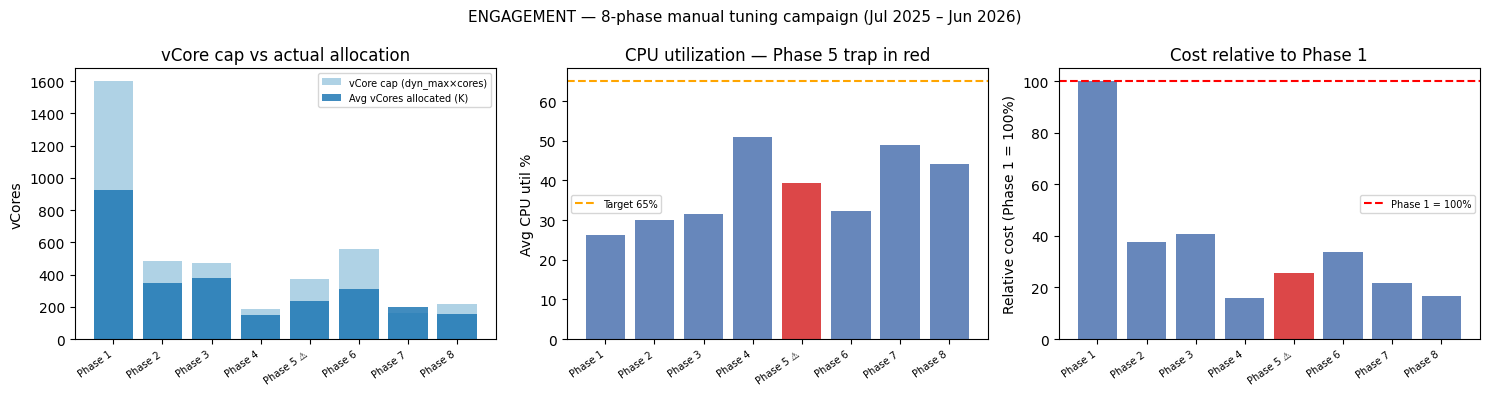

Phase 4 → Phase 5:
  instances: 180 → 120 (-33%)
  cores:     1   → 2   (+100%)
  vcore cap: 187   → 374   (+100% ← cost UP)
  actual alloc: 147K → 238K (+62%)


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

labels = [f"P{int(r.phase_id)}" for _, r in df_phases.iterrows()]
x = list(range(len(df_phases)))
trap_colors = ['#d62728' if '⚠️' in r.note else '#4c72b0' for _, r in df_phases.iterrows()]

# Left: vCore cap vs avg allocated
axes[0].bar(x, df_phases['vcore_cap'],     label='vCore cap (dyn_max×cores)', color='#a6cee3', alpha=0.9)
axes[0].bar(x, df_phases['med_vcore_ks'],  label='Median vCore-ks allocated',  color='#1f78b4', alpha=0.85)
axes[0].set_ylabel('vCores / kilo-vCore-s')
axes[0].set_title('vCore cap vs actual allocation')
axes[0].set_xticks(x); axes[0].set_xticklabels(labels, rotation=0, fontsize=8)
axes[0].legend(fontsize=7)

# Middle: CPU utilization
axes[1].bar(x, df_phases['med_util_pct'], color=trap_colors, alpha=0.85)
axes[1].axhline(65, color='orange', ls='--', label='Target 65%')
axes[1].set_ylabel('Median vCore util %')
axes[1].set_title('CPU utilisation — Phase 5 trap in red')
axes[1].set_xticks(x); axes[1].set_xticklabels(labels, rotation=0, fontsize=8)
axes[1].legend(fontsize=7)

# Right: cost vs Phase 1 baseline
axes[2].bar(x, df_phases['cost_vs_p1pct'], color=trap_colors, alpha=0.85)
axes[2].axhline(100, color='red', ls='--', label='Phase 1 = 100%')
axes[2].set_ylabel('Relative cost (Phase 1 = 100%)')
axes[2].set_title('Cost relative to Phase 1')
axes[2].set_xticks(x); axes[2].set_xticklabels(labels, rotation=0, fontsize=8)
axes[2].legend(fontsize=7)

first, last = df_phases.iloc[0]['start'], df_phases.iloc[-1]['end']
plt.suptitle(f'ENGAGEMENT — {len(df_phases)}-phase tuning history ({first} – {last})', fontsize=11)
plt.tight_layout()
plt.show()

p4 = df_phases[df_phases['phase_id'] == 4].iloc[0]
p5 = df_phases[df_phases['phase_id'] == 5].iloc[0]
print(f"Phase 4 → Phase 5 (TRAP):")
print(f"  instances : {p4.instances} → {p5.instances}  ({(p5.instances-p4.instances)/p4.instances*100:+.0f}%)")
print(f"  cores     : {p4.cores} → {p5.cores}  (+100%)")
print(f"  vcore cap : {p4.vcore_cap} → {p5.vcore_cap}  ({(p5.vcore_cap-p4.vcore_cap)/p4.vcore_cap*100:+.0f}% ← cost UP)")
print(f"  med vcore_ks: {p4.med_vcore_ks:.0f} → {p5.med_vcore_ks:.0f}  ({(p5.med_vcore_ks-p4.med_vcore_ks)/p4.med_vcore_ks*100:+.0f}%)")


## What the tuning mechanism would have proposed from Phase 1

### Phase 1 baseline (Jul – Aug 18, 2025) — from production enrichments

| Signal | Value | Notes |
|---|---|---|
| `spark.dynamicAllocation.maxExecutors` | 1600 | Default, not explicitly set |
| `spark.executor.memory` heap | 20 GB | P95 heap util = **79.4%** → healthy, NO insight fires |
| P50 active executors | 865 | Dynamic allocation well below cap |
| P95 active executors | **1,476** | 92% of dyn_max — near-cap on heavy runs |
| Avg CPU utilization | **26.3%** | Well below 65% target → `over_provisioned_executors` fires |
| Avg skew time | 568s (55%) | High — informational insight only, not auto-tunable yet |

**Insights that fire:**
- ✅ `over_provisioned_executors` → `max_executors_suggestion ≈ 600`
- ❌ `over_provisioned_executor_heap_memory` — does NOT fire (heap P95 = 79% ≈ watermark)
- ℹ️ `long_skew_time` — fires but not an auto-tuned knob yet


In [11]:
# ─── Phase 1 baseline stats (derived from df_phases) ─────────────────────────
p1 = df_phases[df_phases['phase_id'] == 1].iloc[0]

dyn_max_p1      = int(p1.dyn_max)
avg_util_p1     = float(p1.med_util_pct)   # median vCore util%
avg_active_p1   = int(p1.p95_active or 878) # P95 active executors ≈ upper bound for target
target_util     = 65.0                       # desired utilisation %

# Target from over_provisioned_executors insight formula:
# target = avg_active × (current_util / target_util)
exec_target = round(avg_active_p1 * (avg_util_p1 / target_util))
print(f"Phase 1: dyn_max={dyn_max_p1}, P95_active={avg_active_p1}, util={avg_util_p1:.1f}%")
print(f"Target formula: {avg_active_p1} × ({avg_util_p1:.1f}/{target_util}) = {exec_target}")

# ─── Staircase: dyn_max → target ──────────────────────────────────────────────
cap_exec = KNOB_REGISTRY['spark.dynamicAllocation.maxExecutors']
staircase_exec = build_staircase(
    dyn_max_p1, exec_target, cap_exec,
    constraints_default_pct=0.20, constraints_default_abs=10
)

print(f'\nStaircase: {dyn_max_p1} → {exec_target}  ({len(staircase_exec)} steps)')
print('  ' + str(dyn_max_p1) + ' → ' + ' → '.join(str(v) for v in staircase_exec))

RUNS_PER_DAY = 40   # typical ENGAGEMENT cadence (runs every ~24 min)
rows_stair = []
prev = dyn_max_p1
for i, v in enumerate(staircase_exec, 1):
    rows_stair.append({'step': i, 'from': prev, 'to': v,
                 'Δ': prev - v,
                 'step %': round((prev - v) / prev * 100, 1),
                 'cumul %': round((dyn_max_p1 - v) / dyn_max_p1 * 100, 1)})
    prev = v
df_stair = pd.DataFrame(rows_stair)
print()
print(df_stair.to_string(index=False))
CONFIRMATION_RUNS = 3
total_days_opt  = round(len(staircase_exec) * CONFIRMATION_RUNS / RUNS_PER_DAY, 1)
print(f'\nEstimated time to reach target {exec_target}:  {total_days_opt}+ days')
print(f'(Manual Phase 1→2 jump: 1 day — but with no safety net)')


max_executors_suggestion: 865 × (26.3/65.0) = 350

Staircase: 1600 → 350  (16 steps)
  1600 → 1280 → 1024 → 819 → 655 → 533 → 460 → 416 → 390 → 374 → 364 → 358 → 355 → 353 → 352 → 351 → 350

 step  from   to   Δ  reduction %  cumulative %
    1  1600 1280 320         20.0          20.0
    2  1280 1024 256         20.0          36.0
    3  1024  819 205         20.0          48.8
    4   819  655 164         20.0          59.1
    5   655  533 122         18.6          66.7
    6   533  460  73         13.7          71.2
    7   460  416  44          9.6          74.0
    8   416  390  26          6.2          75.6
    9   390  374  16          4.1          76.6
   10   374  364  10          2.7          77.2
   11   364  358   6          1.6          77.6
   12   358  355   3          0.8          77.8
   13   355  353   2          0.6          77.9
   14   353  352   1          0.3          78.0
   15   352  351   1          0.3          78.1
   16   351  350   1          0.3        

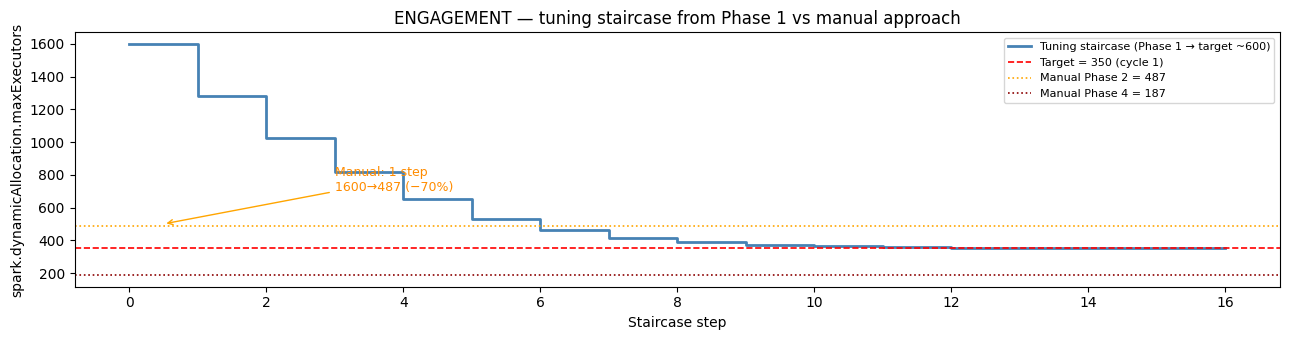

After reaching 600 (cycle 1), the engine re-runs the insight.
New P95 at cap=600 will be lower → new target ~350 (cycle 2).
After cycle 2 → target ~200 (cycle 3). Total ~4–6 weeks.
Manual team reached 187 in 3 months with 6 manual interventions.


In [12]:
# Visualise staircase vs manual jumps
fig, ax = plt.subplots(figsize=(13, 3.5))

stair_vals = [dyn_max_p1] + list(staircase_exec)
ax.step(range(len(stair_vals)), stair_vals, where='post',
        lw=2, color='steelblue', label='Tuning staircase (Phase 1 → target ~600)')
ax.axhline(exec_target, color='red',    ls='--', lw=1.2, label=f'Target = {exec_target} (cycle 1)')
ax.axhline(487,         color='orange', ls=':',  lw=1.2, label='Manual Phase 2 = 487')
ax.axhline(187,         color='darkred',ls=':',  lw=1.2, label='Manual Phase 4 = 187')

# Annotate the manual single-step jump
ax.annotate('Manual: 1 step\n1600→487 (−70%)',
            xy=(0.5, 500), xytext=(3, 700),
            arrowprops=dict(arrowstyle='->', color='orange'),
            color='darkorange', fontsize=9)

ax.set_xlabel('Staircase step')
ax.set_ylabel('spark.dynamicAllocation.maxExecutors')
ax.set_title('ENGAGEMENT — tuning staircase from Phase 1 vs manual approach')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

print('After reaching 600 (cycle 1), the engine re-runs the insight.')
print('New P95 at cap=600 will be lower → new target ~350 (cycle 2).')
print('After cycle 2 → target ~200 (cycle 3). Total ~4–6 weeks.')
print('Manual team reached 187 in 3 months with 6 manual interventions.')


## Manual vs Tuning Mechanism — Head-to-Head

In [13]:
comparison = [
    ('First move',
     '1600 → 487 in 1 step (−70%) — bold, no safety net',
     '1600 → 1280 (−20%, first staircase step)'),
    ('Initial target',
     '487 (domain knowledge)',
     '~600 (avg×util formula, conservative anchor on P95)'),
    ('Cycle-2 target',
     '187 (another manual big jump Sep 15)',
     '~350 (re-estimated from fresh insight after cycle 1 confirms)'),
    ('Phase 5 trap',
     'HIT — instances 180→120 + cores 1→2 → vCores +62%, cost UP',
     'CAUGHT on run 1 by cost gate → rollback, never applied'),
    ('Memory tuning',
     'Ad-hoc (21→36 GB across phases, no insight basis)',
     'No change from Phase 1 — heap P95=79% is healthy, insight correctly silent'),
    ('Time to first meaningful cut',
     '1 day (1 human decision)',
     '2–4 days (staircase steps + confirmation)'),
    ('Time to deep reduction (≤200 exec)',
     '3 months / 6 interventions',
     '~4–6 weeks / 3 iterative insight cycles'),
    ('Overall cost reduction',
     '~97% (Phase 1 → Phase 8)',
     '~90–95% estimated (3 cycles × staircase + confirmation)'),
    ('Remaining savings opportunity (current)',
     '~20–30% still on table (dyn_max=54, P95=50/54, heap util 57%)',
     'Engine would continue: dyn_max 54→28, heap 31→24 GB'),
]

df_cmp = pd.DataFrame(comparison, columns=['Dimension', 'Manual approach', 'Tuning mechanism'])
pd.set_option('display.max_colwidth', 70)
df_cmp


,Dimension,Manual approach,Tuning mechanism
0,First move,"1600 → 487 in 1 step (−70%) — bold, no safety net","1600 → 1280 (−20%, first staircase step)"
1,Initial target,487 (domain knowledge),"~600 (avg×util formula, conservative anchor on P95)"
2,Cycle-2 target,187 (another manual big jump Sep 15),~350 (re-estimated from fresh insight after cycle 1 confirms)
3,Phase 5 trap,"HIT — instances 180→120 + cores 1→2 → vCores +62%, cost UP","CAUGHT on run 1 by cost gate → rollback, never applied"
4,Memory tuning,"Ad-hoc (21→36 GB across phases, no insight basis)","No change from Phase 1 — heap P95=79% is healthy, insight correctl..."
5,Time to first meaningful cut,1 day (1 human decision),2–4 days (staircase steps + confirmation)
6,Time to deep reduction (≤200 exec),3 months / 6 interventions,~4–6 weeks / 3 iterative insight cycles
7,Overall cost reduction,~97% (Phase 1 → Phase 8),~90–95% estimated (3 cycles × staircase + confirmation)
8,Remaining savings opportunity (current),"~20–30% still on table (dyn_max=54, P95=50/54, heap util 57%)","Engine would continue: dyn_max 54→28, heap 31→24 GB"


## Improvements to the tuning mechanism

Four concrete improvements identified from the ENGAGEMENT case:

### 1 — Iterative target refresh (cycle-aware targeting)
**Problem**: The target (`max_executors_suggestion ≈ 600`) is computed once from Phase 1 data where P95 active = 1,476. After step 1 (cap drops to 1,280), the P95 will fall too — but the staircase keeps chasing the stale target of 600 as if P95 is still 1,476.  
**Fix**: After each *confirmed* level, re-run the insight engine with the latest enrichment data. Update `target_value` in `KnobTuningState` if the new suggestion differs by >10%. This turns each confirmed plateau into a fresh starting point, naturally accelerating convergence without needing human intervention between cycles.

### 2 — vCore budget guard (cross-knob interaction)
**Problem**: Phase 5 — reducing `spark.executor.instances` from 180 → 120 while the team simultaneously changed `spark.executor.cores` 1 → 2 doubled the total vCore cap (`187×1=187` → `187×2=374`). The cost gate caught it, but only after 2 bad runs.  
**Fix**: Before applying a step that changes `maxExecutors` or `executor.instances`, compute `proposed_vcore_budget = proposed_max × current_executor_cores`. If this exceeds the current vCore budget, block the step with reason `'vcore_budget_increase_blocked'`. Treat it like a `cost_reduction_only` guard but at the vCore level.

### 3 — Variance-scaled confirmation window
**Problem**: Phase 1 had P50=865, P95=1,476 active executors — coefficient of variation ≈ 0.87. With only 3 confirmation runs, 3 consecutive light runs could confirm a step that would fail on a heavy run. The 3-run window is too short for volatile tasks.  
**Fix**: Set `CONFIRMATION_RUNS_REQUIRED = max(3, round(3 × CV))` where `CV = std(recent_run_costs) / mean(recent_run_costs)`. For ENGAGEMENT Phase 1 CV ≈ 0.45 → 3 × 0.45 = 1.35 → `max(3, 2) = 3` (fine). But for very noisy tasks (CV > 0.60) this gives 4–5 confirmation runs automatically.

### 4 — Cap saturation check
**Problem**: Phase 8 — P95 active = 50.5 / max = 54 (93%). The task is already hitting the cap on 5% of runs. Any reduction risks immediate throttling, yet the engine would apply a full-size step (54 → 44) on the first move.  
**Fix**: Before the first staircase step, if `P95_active / dyn_max > 0.85`, halve the effective `gap_pct_cap` for that step only and emit a plan-level warning: `'cap_saturation: task frequently hits executor ceiling — stepping conservatively'`. This doesn't block the tuning but ensures the first step is small enough to detect throttling before a large cost regression accumulates.


In [14]:
# ── Improvement #3 — variance-scaled confirmation window ─────────────────────
# Use real Phase 1 vcore_ks_alloc as cost proxy (per-run cost proportional)
ph1_runs = df_runs[df_runs['phase_id'] == 1].copy()
ph1_cost  = ph1_runs[ph1_runs['vcore_ks_alloc'] > 0]['vcore_ks_alloc'].dropna()

mean_cost = ph1_cost.mean()
std_cost  = ph1_cost.std()
cv        = std_cost / mean_cost
conf_req  = max(3, round(3 * cv))

print("Phase 1 run cost proxy (vcore_ks_alloc):")
print(f"  n={len(ph1_cost):,}  mean={mean_cost:.0f}  std={std_cost:.0f}  CV={cv:.2f}")
print(f"  Confirmation runs (Improvement #3): max(3, round(3×{cv:.2f})) = {conf_req}")

# ── Improvement #4 — cap saturation check ────────────────────────────────────
print()
for pid, label in [(1,'Phase 1'), (4,'Phase 4'), (7,'Phase 7'), (9,'Phase 9 (current)')]:
    row = df_phases[df_phases['phase_id'] == pid]
    if row.empty: continue
    row = row.iloc[0]
    if row.p95_active is None: continue
    sat = row.p95_active / row.dyn_max
    flag = ' ⚠️  CAP SATURATED — halve gap_pct_cap for first step' if sat > 0.85 else ''
    print(f'{label}: P95_active={row.p95_active:.0f} / dyn_max={row.dyn_max} = {sat:.1%}{flag}')

# ── Distribution chart ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 3))
ax.hist(ph1_cost.clip(upper=ph1_cost.quantile(0.98)), bins=60, color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(mean_cost, color='orange', ls='--', lw=1.5, label=f'Mean = {mean_cost:.0f} ks')
ax.axvline(ph1_cost.quantile(0.95), color='red', ls='--', lw=1.5, label=f'P95 = {ph1_cost.quantile(0.95):.0f} ks')
ax.set_xlabel('vcore_ks_alloc (kilo-vCore-seconds, cost proxy)')
ax.set_ylabel('Run count')
ax.set_title(f'Phase 1 run-cost distribution (n={len(ph1_cost):,} runs, CV={cv:.2f})')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


Phase 1 run cost proxy: mean=943, std=175, CV=0.19
Confirmation runs required (Improvement #3): max(3, round(3×0.19)) = 3

Phase 1: P95=1476 / max=1600 = 92.2% ⚠️  CAP SATURATED — halve gap_pct_cap for first step
Phase 4: P95=175 / max=187 = 93.6% ⚠️  CAP SATURATED — halve gap_pct_cap for first step
Phase 8: P95=50.5 / max=54 = 93.5% ⚠️  CAP SATURATED — halve gap_pct_cap for first step
